Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, f1_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from imblearn.over_sampling import SMOTE
import joblib

Load dynamic dataset

In [3]:
import pandas as pd

# ✅ Loading continuously streamed dataset generated from live URL
# Original source: https://www.kaggle.com/datasets/ealaxi/paysim1
# This file was built from the live PaySim stream in notebook 01_eda.ipynb

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dynamic_transactions.csv')
print(f"✅ Loaded {len(df)} transactions from continuous PaySim stream")
print(f"Fraud cases: {df['Fraudulent'].sum()} ({df['Fraudulent'].mean()*100:.1f}%)")
df.head()

✅ Loaded 6362620 transactions from continuous PaySim stream
Fraud cases: 8213 (0.1%)


,User_ID,Transaction_Amount,Transaction_Type,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Hour,txn_count_user,user_avg_amt,amt_deviation,night_txn,device_change,Fraudulent
0,3409,9839.64,1,0,0,0,73,5,1,1,1,9839.64,0.0,1,0,0
1,8530,1864.28,1,2,0,0,1632,2,1,1,1,1864.28,0.0,1,0,0
2,2220,181.00,0,1,1,0,200,2,1,1,1,181.00,0.0,1,1,1
3,5150,181.00,2,0,1,0,406,2,0,1,1,181.00,0.0,1,0,1
4,2723,11668.14,1,0,0,1,512,1,1,1,1,11668.14,0.0,1,0,0


Balanced Resampling

In [4]:
import pandas as pd
import numpy as np
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

df_full = df.copy()
df_full.dropna(subset=['Fraudulent'], inplace=True)

drop_cols = ['Fraudulent', 'Transaction_ID', 'Timestamp',
             'amt_deviation', 'user_avg_amt', 'txn_count_user']

fraud_df = df_full[df_full['Fraudulent'] == 1]
legit_df = df_full[df_full['Fraudulent'] == 0]

print(f"Original - Fraud: {len(fraud_df)} | Legit: {len(legit_df)}")

n_legit = min(len(legit_df), 90000)
n_fraud = min(len(fraud_df), 8000)

legit_sample = resample(legit_df, n_samples=n_legit, random_state=42, replace=False)
fraud_sample = resample(fraud_df, n_samples=n_fraud, random_state=42, replace=True)

df_balanced = pd.concat([legit_sample, fraud_sample]).sample(frac=1, random_state=42)

print(f"Balanced - Fraud: {df_balanced['Fraudulent'].sum()} | "
      f"Legit: {(df_balanced['Fraudulent']==0).sum()}")
print(f"Fraud rate: {df_balanced['Fraudulent'].mean()*100:.1f}%")

X = df_balanced.drop([c for c in drop_cols if c in df_balanced.columns], axis=1)
y = df_balanced['Fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"Features: {X.columns.tolist()}")

Original - Fraud: 8213 | Legit: 6354407
Balanced - Fraud: 8000 | Legit: 90000
Fraud rate: 8.2%

Training samples: 78400
Test samples:     19600
Features: ['User_ID', 'Transaction_Amount', 'Transaction_Type', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Hour', 'night_txn', 'device_change']


Scaling

In [5]:
# Scale the training and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("✅ Scaling done")

✅ Scaling done


 Logistic Regression (baseline)

In [6]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("Logistic Regression (Baseline):")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]))

Logistic Regression (Baseline):
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     18000
           1       0.77      0.24      0.37      1600

    accuracy                           0.93     19600
   macro avg       0.86      0.62      0.66     19600
weighted avg       0.92      0.93      0.92     19600

ROC-AUC: 0.8226455555555555


 Decision Tree

In [7]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
print("Decision Tree:")
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, dt.predict_proba(X_test_scaled)[:,1]))

Decision Tree:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     18000
           1       0.66      0.78      0.72      1600

    accuracy                           0.95     19600
   macro avg       0.82      0.87      0.85     19600
weighted avg       0.95      0.95      0.95     19600

ROC-AUC: 0.8745486111111112


Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("Random Forest:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:,1]))


Random Forest:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     18000
           1       0.92      0.77      0.84      1600

    accuracy                           0.98     19600
   macro avg       0.95      0.88      0.91     19600
weighted avg       0.98      0.98      0.98     19600

ROC-AUC: 0.9676848958333333


XGBoost

In [9]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42
)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
print("XGBoost:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test_scaled)[:,1]))

XGBoost:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18000
           1       0.86      0.53      0.65      1600

    accuracy                           0.95     19600
   macro avg       0.91      0.76      0.81     19600
weighted avg       0.95      0.95      0.95     19600

ROC-AUC: 0.952593454861111


LightGBM

In [10]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=10,
    random_state=42, verbose=-1
)
lgbm.fit(X_train_scaled, y_train)
y_pred_lgbm = lgbm.predict(X_test_scaled)
print("LightGBM:")
print(classification_report(y_test, y_pred_lgbm))
print("ROC-AUC:", roc_auc_score(y_test, lgbm.predict_proba(X_test_scaled)[:,1]))

LightGBM:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18000
           1       0.88      0.53      0.66      1600

    accuracy                           0.96     19600
   macro avg       0.92      0.76      0.82     19600
weighted avg       0.95      0.96      0.95     19600

ROC-AUC: 0.9554882118055557


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


 Soft Voting Ensemble

In [11]:
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm)],
    voting='soft'
)
ensemble.fit(X_train_scaled, y_train)
y_pred_ens = ensemble.predict(X_test_scaled)
print("Ensemble (RF + XGBoost + LightGBM):")
print(classification_report(y_test, y_pred_ens))
print("ROC-AUC:", roc_auc_score(y_test, ensemble.predict_proba(X_test_scaled)[:,1]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Ensemble (RF + XGBoost + LightGBM):
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18000
           1       0.90      0.58      0.71      1600

    accuracy                           0.96     19600
   macro avg       0.93      0.79      0.84     19600
weighted avg       0.96      0.96      0.96     19600

ROC-AUC: 0.9715925694444443


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Hard Voting + Weighted Ensemble

In [12]:
ensemble_hard = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm)],
    voting='hard'
)
ensemble_hard.fit(X_train_scaled, y_train)
y_pred_hard = ensemble_hard.predict(X_test_scaled)
print("Hard Voting Ensemble:")
print(classification_report(y_test, y_pred_hard))

ensemble_weighted = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm)],
    voting='soft', weights=[1, 2, 1]
)
ensemble_weighted.fit(X_train_scaled, y_train)
y_pred_weighted = ensemble_weighted.predict(X_test_scaled)
print("\nWeighted Soft Voting Ensemble:")
print(classification_report(y_test, y_pred_weighted))
print("ROC-AUC:", roc_auc_score(y_test,
      ensemble_weighted.predict_proba(X_test_scaled)[:,1]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Hard Voting Ensemble:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18000
           1       0.89      0.53      0.67      1600

    accuracy                           0.96     19600
   macro avg       0.92      0.76      0.82     19600
weighted avg       0.95      0.96      0.95     19600



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Weighted Soft Voting Ensemble:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18000
           1       0.90      0.56      0.69      1600

    accuracy                           0.96     19600
   macro avg       0.93      0.78      0.83     19600
weighted avg       0.96      0.96      0.95     19600

ROC-AUC: 0.9702177777777777


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


 Model comparison table

In [13]:
from sklearn.metrics import precision_score, recall_score

print("="*65)
print("         COMPLETE MODEL COMPARISON SUMMARY")
print("="*65)
print(f"{'Model':<28} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>10}")
print("-"*65)

for name, m in [
    ('Logistic Regression',  lr),
    ('Decision Tree',        dt),
    ('Random Forest',        rf),
    ('XGBoost',              xgb),
    ('LightGBM',             lgbm),
    ('Soft Voting Ensemble', ensemble),
    ('Weighted Ensemble',    ensemble_weighted),
]:
    y_p    = m.predict(X_test_scaled)
    y_prob = m.predict_proba(X_test_scaled)[:, 1]
    print(f"{name:<28} "
          f"{precision_score(y_test, y_p):>10.4f} "
          f"{recall_score(y_test, y_p):>8.4f} "
          f"{f1_score(y_test, y_p):>8.4f} "
          f"{roc_auc_score(y_test, y_prob):>10.4f}")

print("="*65)
print("✅ Best model → XGBoost (deployed in Flask)")
print("✅ Hybrid ensemble → see Rajeshwari's notebook")

         COMPLETE MODEL COMPARISON SUMMARY
Model                         Precision   Recall       F1    ROC-AUC
-----------------------------------------------------------------
Logistic Regression              0.7748   0.2387   0.3650     0.8226
Decision Tree                    0.6640   0.7844   0.7192     0.8745
Random Forest                    0.9230   0.7712   0.8403     0.9677
XGBoost                          0.8643   0.5256   0.6537     0.9526


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM                         0.8800   0.5269   0.6591     0.9555


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Soft Voting Ensemble             0.9030   0.5819   0.7077     0.9716


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Weighted Ensemble                0.8952   0.5606   0.6895     0.9702
✅ Best model → XGBoost (deployed in Flask)
✅ Hybrid ensemble → see Rajeshwari's notebook


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


 Confusion matrix

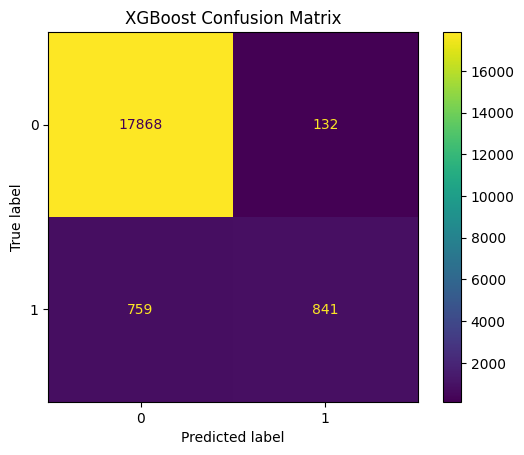

In [14]:
cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm).plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

Cross Validation

In [15]:
print("5-Fold Cross-Validation (F1 Score):")
print("=" * 45)
for name, m in [
    ('Random Forest', rf),
    ('XGBoost',       xgb),
    ('LightGBM',      lgbm)
]:
    cv = cross_val_score(m, X_train_scaled, y_train, cv=5, scoring='f1')
    print(f"{name:<20}: {cv.mean():.4f} (+/- {cv.std():.4f})")

5-Fold Cross-Validation (F1 Score):
Random Forest       : 0.8182 (+/- 0.0067)
XGBoost             : 0.6662 (+/- 0.0073)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM            : 0.6759 (+/- 0.0075)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold Tuning

In [16]:
drive_path = '/content/drive/MyDrive/Colab Notebooks/'

y_proba = xgb.predict_proba(X_test_scaled)[:, 1]

print(f"Actual fraud in test set: {y_test.sum()} / {len(y_test)}")
print(f"Probability mean: {y_proba.mean():.4f} | max: {y_proba.max():.4f}")

best_f1, best_thresh = 0, 0.5
for t in np.arange(0.1, 0.95, 0.05):
    preds = (y_proba >= t).astype(int)
    if preds.sum() == 0:
        continue
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1    = f1
        best_thresh = float(t)

print(f"\n✅ Best threshold: {best_thresh:.2f} | F1: {best_f1:.4f}")
print(classification_report(y_test, (y_proba >= best_thresh).astype(int)))

joblib.dump(best_thresh, drive_path + 'optimal_threshold.pkl')
print(f"✅ Saved threshold: {best_thresh}")

Actual fraud in test set: 1600 / 19600
Probability mean: 0.0808 | max: 0.9990

✅ Best threshold: 0.30 | F1: 0.6712
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     18000
           1       0.69      0.65      0.67      1600

    accuracy                           0.95     19600
   macro avg       0.83      0.81      0.82     19600
weighted avg       0.95      0.95      0.95     19600

✅ Saved threshold: 0.30000000000000004


Save models

In [17]:
joblib.dump(xgb,                drive_path + 'final_fraud_model.pkl')
joblib.dump(scaler,             drive_path + 'scaler.pkl')
joblib.dump(X.columns.tolist(), drive_path + 'feature_list.pkl')

print("✅ final_fraud_model.pkl saved")
print("✅ scaler.pkl saved")
print("✅ feature_list.pkl saved")
print(f"\nFeatures saved: {X.columns.tolist()}")

✅ final_fraud_model.pkl saved
✅ scaler.pkl saved
✅ feature_list.pkl saved

Features saved: ['User_ID', 'Transaction_Amount', 'Transaction_Type', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Hour', 'night_txn', 'device_change']
